In [43]:
import pandas as pd
import numpy as np

train = pd.read_csv('/content/train.csv')

In [44]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                911 non-null    int64  
 1   date              911 non-null    object 
 2   meals_served      911 non-null    int64  
 3   kitchen_staff     911 non-null    int64  
 4   temperature_C     911 non-null    float64
 5   humidity_percent  911 non-null    float64
 6   day_of_week       911 non-null    int64  
 7   special_event     911 non-null    int64  
 8   past_waste_kg     911 non-null    float64
 9   staff_experience  747 non-null    object 
 10  waste_category    911 non-null    object 
 11  food_waste_kg     911 non-null    float64
dtypes: float64(4), int64(5), object(3)
memory usage: 85.5+ KB


In [45]:
train['staff_experience'] = train['staff_experience'].fillna(train['staff_experience'].mode()[0])

In [46]:
print(train.isnull().sum())

ID                  0
date                0
meals_served        0
kitchen_staff       0
temperature_C       0
humidity_percent    0
day_of_week         0
special_event       0
past_waste_kg       0
staff_experience    0
waste_category      0
food_waste_kg       0
dtype: int64


In [47]:
train.head(2)

,ID,date,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,food_waste_kg
0,0,2022-12-19,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy,28.946465
1,1,2023-11-21,244,15,10.317872,64.430475,1,0,42.311779,Beginner,MeAt,51.549053


In [48]:
train = train.drop(['special_event', 'ID','date'], axis=1)

In [49]:
print('Train columns after dropping: ', train.columns)

Train columns after dropping:  Index(['meals_served', 'kitchen_staff', 'temperature_C', 'humidity_percent',
       'day_of_week', 'past_waste_kg', 'staff_experience', 'waste_category',
       'food_waste_kg'],
      dtype='object')


In [50]:
train.sample(2)

,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,past_waste_kg,staff_experience,waste_category,food_waste_kg
236,200,7,26.303081,57.007402,2,6.161423,intermediate,MEAT,15.029168
302,157,7,10.500659,37.776039,0,15.603028,Beginner,GRAINS,29.628702


In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np


X = train.drop('food_waste_kg', axis=1)
y = train['food_waste_kg']


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), [6,7])

    ] , remainder='passthrough'
)


X_processed = preprocessor.fit_transform(X)
# Removed test_processed as evaluation will be on X_val

X_train, X_val, y_train, y_val = train_test_split(X_processed, y, test_size=0.2, random_state=42)


model = RandomForestRegressor(n_estimators=100, random_state=42)


model.fit(X_train, y_train)


y_pred_rf = model.predict(X_val) # Predict on the validation set

In [52]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


mse_test = mean_squared_error(y_val, y_pred_rf) # Evaluate against y_val
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_val, y_pred_rf) # Evaluate against y_val

print(f"Mean Squared Error (Validation): {mse_test:.4f}")
print(f"Root Mean Squared Error (Validation): {rmse_test:.4f}")
print(f"R-squared (Validation): {r2_test:.4f}")

Mean Squared Error (Validation): 50.0654
Root Mean Squared Error (Validation): 7.0757
R-squared (Validation): 0.9023


In [53]:
from sklearn.ensemble import GradientBoostingRegressor


gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_val) # Predict on the validation set

In [54]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


mse_gb = mean_squared_error(y_val, y_pred_gb) # Evaluate against y_val
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_val, y_pred_gb) # Evaluate against y_val

print(f"Gradient Boosting Mean Squared Error (Validation): {mse_gb:.4f}")
print(f"Gradient Boosting Root Mean Squared Error (Validation): {rmse_gb:.4f}")
print(f"Gradient Boosting R-squared (Validation): {r2_gb:.4f}")

Gradient Boosting Mean Squared Error (Validation): 70.8053
Gradient Boosting Root Mean Squared Error (Validation): 8.4146
Gradient Boosting R-squared (Validation): 0.8618


### Decision Tree Regressor

In [55]:
from sklearn.tree import DecisionTreeRegressor


dt_model = DecisionTreeRegressor(random_state=42)


dt_model.fit(X_train, y_train)


y_pred_dt = dt_model.predict(X_val) # Predict on the validation set


mse_dt = mean_squared_error(y_val, y_pred_dt) # Evaluate against y_val
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_val, y_pred_dt) # Evaluate against y_val

print(f"Decision Tree Mean Squared Error (Validation): {mse_dt:.4f}")
print(f"Decision Tree Root Mean Squared Error (Validation): {rmse_dt:.4f}")
print(f"Decision Tree R-squared (Validation): {r2_dt:.4f}")

Decision Tree Mean Squared Error (Validation): 127.8290
Decision Tree Root Mean Squared Error (Validation): 11.3061
Decision Tree R-squared (Validation): 0.7505


### Linear Regression

In [56]:
from sklearn.linear_model import LinearRegression


lr_model = LinearRegression()


lr_model.fit(X_train, y_train)


y_pred_lr = lr_model.predict(X_val) # Predict on the validation set


mse_lr = mean_squared_error(y_val, y_pred_lr) # Evaluate against y_val
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_val, y_pred_lr) # Evaluate against y_val

print(f"Linear Regression Mean Squared Error (Validation): {mse_lr:.4f}")
print(f"Linear Regression Root Mean Squared Error (Validation): {rmse_lr:.4f}")
print(f"Linear Regression R-squared (Validation): {r2_lr:.4f}")

Linear Regression Mean Squared Error (Validation): 134.5019
Linear Regression Root Mean Squared Error (Validation): 11.5975
Linear Regression R-squared (Validation): 0.7375


### Neural Network (Multi-layer Perceptron Regressor)

In [57]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val) # Scale the validation set


mlp_model = MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=500, random_state=42)


mlp_model.fit(X_train_scaled, y_train)


y_pred_mlp = mlp_model.predict(X_val_scaled) # Predict on the scaled validation set


mse_mlp = mean_squared_error(y_val, y_pred_mlp) # Evaluate against y_val
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(y_val, y_pred_mlp) # Evaluate against y_val

print(f"Neural Network (MLP) Mean Squared Error (Validation): {mse_mlp:.4f}")
print(f"Neural Network (MLP) Root Mean Squared Error (Validation): {rmse_mlp:.4f}")
print(f"Neural Network (MLP) R-squared (Validation): {r2_mlp:.4f}")

Neural Network (MLP) Mean Squared Error (Validation): 143.4498
Neural Network (MLP) Root Mean Squared Error (Validation): 11.9771
Neural Network (MLP) R-squared (Validation): 0.7200


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [58]:
import pandas as pd


results = {
    'Model': ['Random Forest', 'Gradient Boosting', 'Decision Tree', 'Linear Regression', 'Neural Network (MLP)'],
    'MSE': [mse_test, mse_gb, mse_dt, mse_lr, mse_mlp],
    'RMSE': [rmse_test, rmse_gb, rmse_dt, rmse_lr, rmse_mlp],
    'R-squared': [r2_test, r2_gb, r2_dt, r2_lr, r2_mlp]
}


results_df = pd.DataFrame(results)


results_df = results_df.sort_values(by='R-squared', ascending=False)


display(results_df)

,Model,MSE,RMSE,R-squared
0,Random Forest,50.065386,7.075690,0.902286
1,Gradient Boosting,70.805343,8.414591,0.861808
2,Decision Tree,127.829021,11.306150,0.750513
3,Linear Regression,134.501898,11.597495,0.737490
4,Neural Network (MLP),143.449821,11.977054,0.720026


#### Visualizing Model Performance (R-squared)

This plot provides a visual comparison of the R-squared scores for all the models evaluated. A higher R-squared value indicates a better fit of the model to the data.

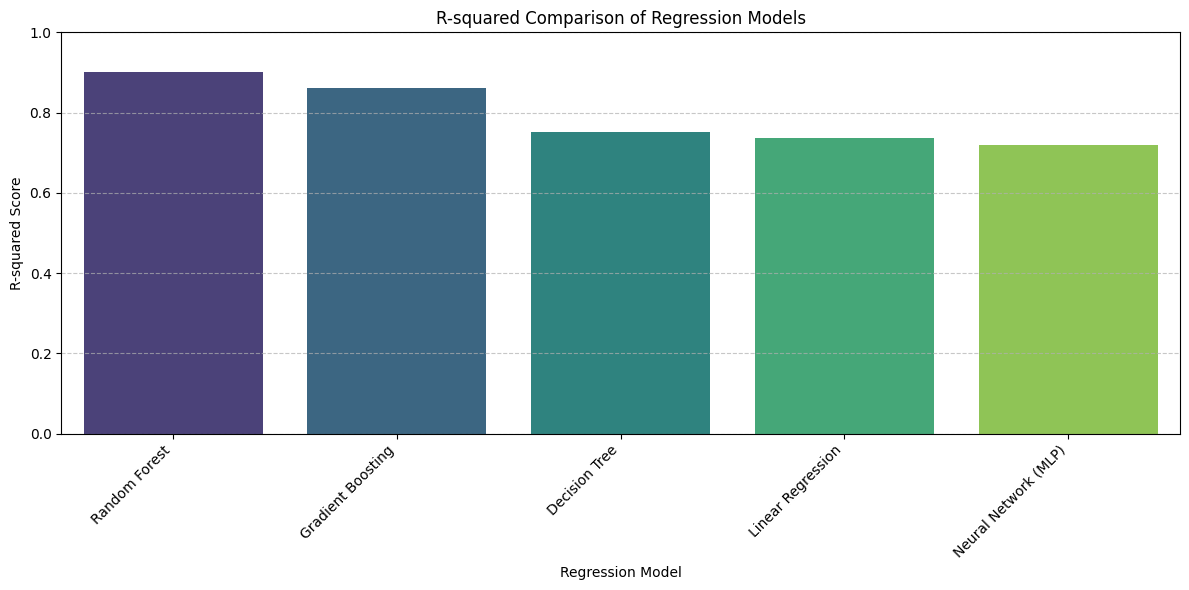

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R-squared', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title('R-squared Comparison of Regression Models')
plt.xlabel('Regression Model')
plt.ylabel('R-squared Score')
plt.ylim(0, 1) # R-squared typically ranges from 0 to 1
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()